In [1]:
"""
Ячейка 1: Создание синтетического датасета для первых экспериментов
В реальности заменишь на собранные данные
"""
import pandas as pd
import random

# Шаблоны фраз по категориям
templates = {
    "order_status": [
        "Где мой заказ {}?",
        "Какой статус заказа {}?",
        "Когда доставят заказ?",
        "Что с моим заказом?",
        "Отследить заказ {}",
        "Мой заказ ещё не пришёл",
        "Когда приедет посылка?",
        "Статус доставки заказа {}",
        "Сколько ждать заказ?",
        "Заказ {} уже отправили?",
    ],
    "payment_refund": [
        "Не проходит оплата",
        "Ошибка при оплате картой",
        "Когда вернут деньги?",
        "Хочу вернуть деньги за заказ",
        "Деньги списали, а заказ не создался",
        "Статус возврата денег",
        "Как оплатить заказ?",
        "Какие способы оплаты?",
        "Возврат средств на карту",
        "Пришлите чек об оплате",
    ],
    "return_exchange": [
        "Хочу вернуть товар",
        "Как оформить возврат?",
        "Можно обменять на другой размер?",
        "Пришёл бракованный товар",
        "Условия возврата товара",
        "Какие сроки возврата?",
        "Товар не подошёл, хочу вернуть",
        "Как вернуть некачественный товар?",
        "Обмен товара на аналогичный",
        "Товар повреждён при доставке",
    ],
    "product_info": [
        "Есть ли в наличии {}?",
        "Какие размеры есть?",
        "Из чего сделан этот товар?",
        "Сколько стоит {}?",
        "Когда появится товар в наличии?",
        "Характеристики товара",
        "Чем отличается модель A от B?",
        "Какой состав ткани?",
        "Подойдёт ли мне размер M?",
        "Есть ли этот товар в другом цвете?",
    ],
    "delivery": [
        "Сколько стоит доставка?",
        "Какие способы доставки?",
        "Доставляете ли в {}?",
        "Есть ли самовывоз?",
        "Хочу изменить адрес доставки",
        "Бесплатная доставка от какой суммы?",
        "Где ближайший пункт выдачи?",
        "Срок доставки в Москву",
        "Можно ли доставить сегодня?",
        "Доставка в выходные работает?",
    ],
    "account": [
        "Не могу войти в аккаунт",
        "Забыл пароль",
        "Как сменить пароль?",
        "Хочу изменить email",
        "Как удалить аккаунт?",
        "Не приходит код подтверждения",
        "Как зарегистрироваться?",
        "Хочу поменять номер телефона",
        "Не могу создать аккаунт",
        "Заблокировали мой аккаунт",
    ],
    "promo_loyalty": [
        "Промокод не работает",
        "Как ввести промокод?",
        "Какие сейчас акции?",
        "Есть ли скидки?",
        "Сколько у меня бонусных баллов?",
        "Как применить скидочный купон?",
        "Промокод {} не активируется",
        "Где найти промокоды?",
        "Как копить бонусные баллы?",
        "Почему промокод не применился?",
    ],
    "technical_issue": [
        "Сайт не работает",
        "Ошибка 500 на странице",
        "Приложение вылетает",
        "Не могу добавить товар в корзину",
        "Страница не загружается",
        "Баг при оформлении заказа",
        "Корзина пустая, хотя я добавлял товары",
        "Фото товара не отображается",
        "Не работает фильтр на сайте",
        "Ошибка при регистрации",
    ],
    "general_info": [
        "Ваш телефон?",
        "Как связаться с вами?",
        "Режим работы магазина",
        "Где находится ваш офис?",
        "Email поддержки",
        "Работаете ли в выходные?",
        "Юридический адрес компании",
        "Где посмотреть оферту?",
        "Политика конфиденциальности",
        "Кто вы такие?",
    ],
    "other": [
        "Хочу пожаловаться на обслуживание",
        "Спасибо, всё отлично!",
        "Мне нужна помощь",
        "Непонятно что делать",
        "У меня сложный вопрос",
        "Посоветуйте что-нибудь",
        "Хочу оставить отзыв",
        "Вы лучший магазин!",
        "Ужасный сервис",
        "Куда писать жалобу?",
    ],
}

# Генерация датасета
data = []
order_nums = [str(random.randint(100000, 999999)) for _ in range(100)]
cities = ["Новосибирск", "Казань", "Екатеринбург", "Самару", "Краснодар"]
products = ["кроссовки Nike", "наушники Sony", "рюкзак", "футболку", "чехол для iPhone"]
promos = ["СКИДКА10", "SALE2026", "ВЕСНА", "НОВЫЙ"]

for category, phrases in templates.items():
    for phrase in phrases:
        # Заменяем плейсхолдеры
        if "{}" in phrase:
            if category == "order_status":
                fillers = order_nums[:5]
            elif category == "delivery":
                fillers = cities
            elif category == "product_info":
                fillers = products
            elif category == "promo_loyalty":
                fillers = promos
            else:
                fillers = [""]
            
            for filler in fillers:
                data.append({"text": phrase.format(filler), "category": category})
        else:
            data.append({"text": phrase, "category": category})

df = pd.DataFrame(data)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"✅ Датасет создан: {len(df)} примеров")
print(f"\n📊 Распределение по категориям:")
print(df['category'].value_counts().to_string())

df.to_csv("../data/synthetic_dataset.csv", index=False)

✅ Датасет создан: 135 примеров

📊 Распределение по категориям:
category
order_status       30
product_info       18
delivery           14
promo_loyalty      13
technical_issue    10
return_exchange    10
other              10
general_info       10
payment_refund     10
account            10


In [2]:
"""
Ячейка 2: Fine-tuning двух моделей и сравнение
"""
import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset
from transformers import AutoTokenizer, AutoModel
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import time

CATEGORIES = list(templates.keys())
cat2id = {c: i for i, c in enumerate(CATEGORIES)}
id2cat = {i: c for c, i in cat2id.items()}

# Dataset class
class TextDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len
    
    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx], truncation=True,
            padding="max_length", max_length=self.max_len,
            return_tensors="pt"
        )
        return {
            "input_ids": enc["input_ids"].squeeze(),
            "attention_mask": enc["attention_mask"].squeeze(),
            "label": torch.tensor(self.labels[idx], dtype=torch.long)
        }

# Classifier class
class Classifier(nn.Module):
    def __init__(self, model_name, num_classes):
        super().__init__()
        self.bert = AutoModel.from_pretrained(model_name)
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(self.bert.config.hidden_size, num_classes)
    
    def forward(self, input_ids, attention_mask):
        out = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        cls = self.dropout(out.last_hidden_state[:, 0, :])
        return self.fc(cls)

# Train function
def train_and_evaluate(model_name, df, epochs=5, batch_size=16, lr=2e-5):
    print(f"\n{'='*60}")
    print(f"🚀 Training: {model_name}")
    print(f"{'='*60}")
    
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    
    texts = df["text"].tolist()
    labels = [cat2id[c] for c in df["category"]]
    
    X_train, X_test, y_train, y_test = train_test_split(
        texts, labels, test_size=0.2, stratify=labels, random_state=42
    )
    
    train_loader = DataLoader(
        TextDataset(X_train, y_train, tokenizer), 
        batch_size=batch_size, shuffle=True
    )
    test_loader = DataLoader(
        TextDataset(X_test, y_test, tokenizer),
        batch_size=batch_size
    )
    
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model = Classifier(model_name, len(CATEGORIES)).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    
    # Training
    train_start = time.time()
    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for batch in train_loader:
            ids = batch["input_ids"].to(device)
            mask = batch["attention_mask"].to(device)
            lbl = batch["label"].to(device)
            
            logits = model(ids, mask)
            loss = criterion(logits, lbl)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        
        avg_loss = total_loss / len(train_loader)
        print(f"  Epoch {epoch+1}/{epochs} | Loss: {avg_loss:.4f}")
    
    train_time = time.time() - train_start
    
    # Evaluation
    model.eval()
    all_preds, all_labels, all_confs = [], [], []
    inference_times = []
    
    with torch.no_grad():
        for batch in test_loader:
            ids = batch["input_ids"].to(device)
            mask = batch["attention_mask"].to(device)
            
            start = time.perf_counter()
            logits = model(ids, mask)
            inf_time = (time.perf_counter() - start) * 1000
            inference_times.append(inf_time / ids.size(0))  # per sample
            
            probs = torch.softmax(logits, dim=1)
            confs, preds = probs.max(dim=1)
            
            all_preds.extend(preds.cpu().tolist())
            all_labels.extend(batch["label"].tolist())
            all_confs.extend(confs.cpu().tolist())
    
    # Report
    report = classification_report(
        all_labels, all_preds,
        target_names=CATEGORIES, digits=3, output_dict=True
    )
    
    print(f"\n  ⏱️  Время обучения:        {train_time:.1f}s")
    print(f"  ⚡ Инференс (per sample):  {np.mean(inference_times):.1f}ms")
    print(f"  🎯 Accuracy:               {report['accuracy']:.3f}")
    print(f"  📊 Macro F1:               {report['macro avg']['f1-score']:.3f}")
    print(f"  📊 Weighted F1:            {report['weighted avg']['f1-score']:.3f}")
    print(f"  📊 Avg Confidence:         {np.mean(all_confs):.3f}")
    
    print(f"\n{classification_report(all_labels, all_preds, target_names=CATEGORIES, digits=3)}")
    
    return {
        "model": model_name,
        "accuracy": report["accuracy"],
        "macro_f1": report["macro avg"]["f1-score"],
        "weighted_f1": report["weighted avg"]["f1-score"],
        "avg_confidence": np.mean(all_confs),
        "train_time_sec": train_time,
        "inference_ms": np.mean(inference_times),
        "all_preds": all_preds,
        "all_labels": all_labels,
    }

# Запуск сравнения (начни с двух — tiny2 быстрый, base подольше)
models_to_compare = [
    "cointegrated/rubert-tiny2",
    "DeepPavlov/rubert-base-cased",
]

all_results = []
for m in models_to_compare:
    result = train_and_evaluate(m, df, epochs=5)
    all_results.append(result)


🚀 Training: cointegrated/rubert-tiny2


Loading weights:   0%|          | 0/55 [00:00<?, ?it/s]

BertModel LOAD REPORT from: cointegrated/rubert-tiny2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Epoch 1/5 | Loss: 2.3100
  Epoch 2/5 | Loss: 2.2461
  Epoch 3/5 | Loss: 2.0956
  Epoch 4/5 | Loss: 2.0570
  Epoch 5/5 | Loss: 1.9501

  ⏱️  Время обучения:        2.0s
  ⚡ Инференс (per sample):  0.6ms
  🎯 Accuracy:               0.296
  📊 Macro F1:               0.120
  📊 Weighted F1:            0.198
  📊 Avg Confidence:         0.211

                 precision    recall  f1-score   support

   order_status      0.353     1.000     0.522         6
 payment_refund      0.000     0.000     0.000         2
return_exchange      0.000     0.000     0.000         2
   product_info      0.143     0.250     0.182         4
       delivery      1.000     0.333     0.500         3
        account      0.000     0.000     0.000         2
  promo_loyalty      0.000     0.000     0.000         2
technical_issue      0.000     0.000     0.000         2
   general_info      0.000     0.000     0.000         2
          other      0.000     0.000     0.000         2

       accuracy               

C:\chat-bot-test\chatbot-ml-explore\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\chat-bot-test\chatbot-ml-explore\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\chat-bot-test\chatbot-ml-explore\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: DeepPavlov/rubert-base-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Epoch 1/5 | Loss: 2.3192
  Epoch 2/5 | Loss: 2.0582
  Epoch 3/5 | Loss: 1.6982
  Epoch 4/5 | Loss: 1.3299
  Epoch 5/5 | Loss: 1.0343

  ⏱️  Время обучения:        80.3s
  ⚡ Инференс (per sample):  1.7ms
  🎯 Accuracy:               0.667
  📊 Macro F1:               0.533
  📊 Weighted F1:            0.592
  📊 Avg Confidence:         0.480

                 precision    recall  f1-score   support

   order_status      0.667     1.000     0.800         6
 payment_refund      0.000     0.000     0.000         2
return_exchange      0.000     0.000     0.000         2
   product_info      0.571     1.000     0.727         4
       delivery      0.667     0.667     0.667         3
        account      1.000     1.000     1.000         2
  promo_loyalty      0.667     1.000     0.800         2
technical_issue      1.000     0.500     0.667         2
   general_info      0.000     0.000     0.000         2
          other      1.000     0.500     0.667         2

       accuracy              

C:\chat-bot-test\chatbot-ml-explore\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\chat-bot-test\chatbot-ml-explore\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\chat-bot-test\chatbot-ml-explore\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is

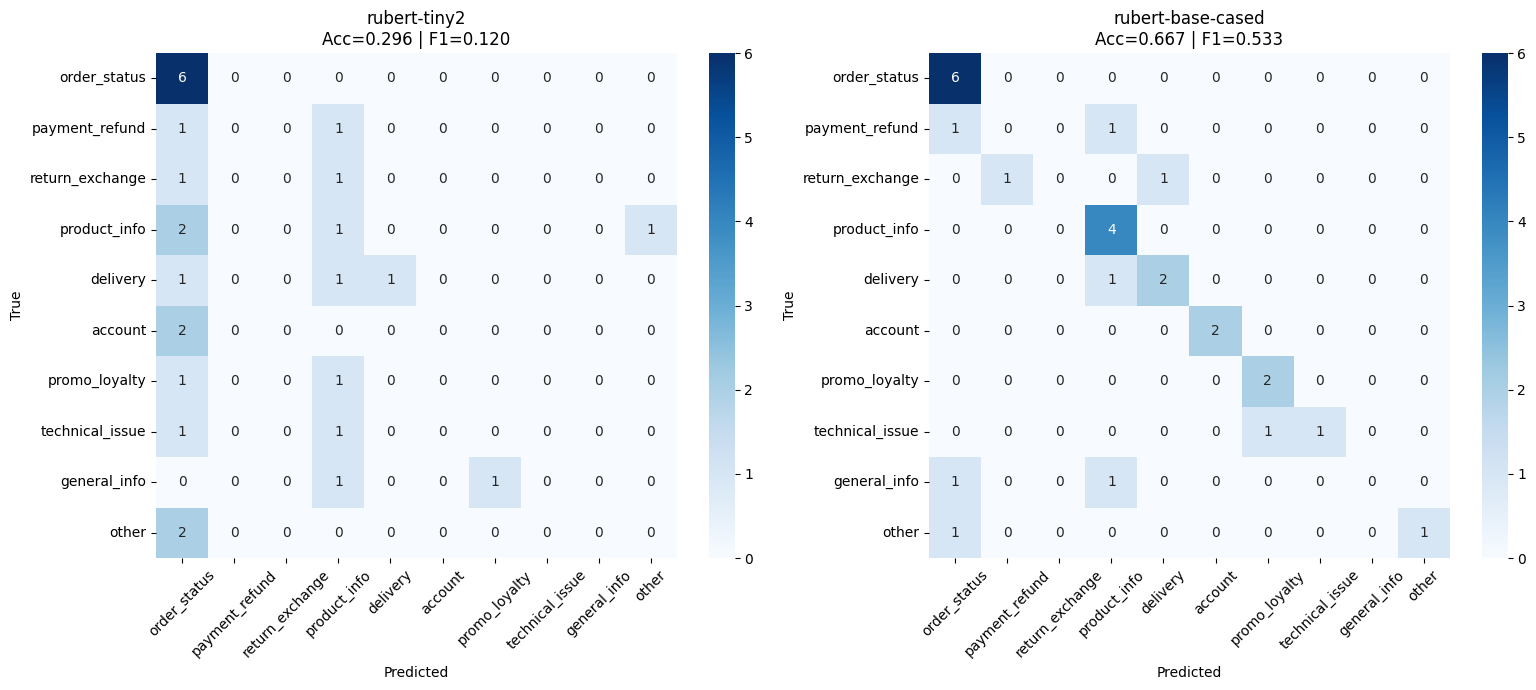


📊 СВОДНАЯ ТАБЛИЦА СРАВНЕНИЯ:
Модель                                        Acc       F1     Conf    Train   Inf/ms
--------------------------------------------------------------------------------
cointegrated/rubert-tiny2                   0.296    0.120    0.211     2.0s     0.6
DeepPavlov/rubert-base-cased                0.667    0.533    0.480    80.3s     1.7


In [3]:
"""
Ячейка 3: Сравнительные графики и confusion matrix
"""
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(1, len(all_results), figsize=(8 * len(all_results), 7))
if len(all_results) == 1:
    axes = [axes]

for idx, result in enumerate(all_results):
    cm = confusion_matrix(result["all_labels"], result["all_preds"])
    
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=CATEGORIES, yticklabels=CATEGORIES,
        ax=axes[idx]
    )
    axes[idx].set_title(
        f"{result['model'].split('/')[-1]}\n"
        f"Acc={result['accuracy']:.3f} | F1={result['macro_f1']:.3f}"
    )
    axes[idx].set_ylabel('True')
    axes[idx].set_xlabel('Predicted')
    axes[idx].tick_params(axis='x', rotation=45)
    axes[idx].tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig('../results/confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

# Сводная таблица
print("\n📊 СВОДНАЯ ТАБЛИЦА СРАВНЕНИЯ:")
print(f"{'Модель':40s} {'Acc':>8s} {'F1':>8s} {'Conf':>8s} {'Train':>8s} {'Inf/ms':>8s}")
print("-" * 80)
for r in all_results:
    print(f"{r['model']:40s} {r['accuracy']:8.3f} {r['macro_f1']:8.3f} "
          f"{r['avg_confidence']:8.3f} {r['train_time_sec']:7.1f}s {r['inference_ms']:7.1f}")